In [29]:
colab = True
if colab:
    !git clone https://github.com/mdrs-thiago/PUC_Redes_Neurais
    import os
    os.chdir('/content/PUC_Redes_Neurais/pos_grad/lista 1')

# Redes Neurais
## 1ª Lista de Exercícios - Classificação de padrões


Estudante:

Base de dados: 

### Para cada item da lista de exercício, não esqueça de fazer uma análise pertinente dos resultados obtidos.

<h1> Importante! </h1>

1. Fique atento com os hiperparâmetros iniciais desta lista. Dependendo do problema, os valores podem mudar. Para encontrar um conjunto de parâmetros razoáveis, siga o seguinte roteiro: 

        1. Rode os itens 2.1 e 3.1 com os parâmetros iniciais. Se os dois resultados foram igualmente ruins, modifique os parâmetros do item 3.1 até que o resultado seja relativamente melhor que o 2.1.

        2. Após obter esses melhores parâmetros iniciais, rode novamente o item 2.1 com os mesmos hiperparâmetros para uma comparação mais justa. 

2. O resultado de um modelo de Redes Neurais geralmente depende da inicialização de seus pesos. Portanto, para cada questão, obtenha um resultado médio de pelo menos 10 rodadas.

In [1]:
import numpy as np 
import pandas as pd 
import json
import matplotlib.pyplot as plt 
import seaborn as sns 
from time import sleep
import requests

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader 

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from utils import CustomDataset, transform_data, plot_confusion_matrix
from model_utils import train

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


In [2]:
class NeuralNetwork(torch.nn.Module):
  '''
  Objeto criado para facilitar o desenvolvimento dos scripts das aulas práticas.
  Opção alternativa à criação externa fdo modelo. Basicamente serve como um 
  'agregador'  de trechos comuns para a criação do modelo. Por exemplo, ao invés
  de gastar n+1 linhas para a criação de um modelo com n camadas, podemos criar 
  o mesmo modelo com apenas uma linha.
  
  Parâmetros de entrada: 
  - hidden_neurons: Lista com a quantidade de neurônios na camada escondida. 
  - hidden_activation: Função de ativação para cada camada escondida. Aceita 
  como parâmetro string ou lista. Caso o parâmetro receba string, então a mesma
  função de ativação é utilizada para todas as camadas escondidas. Caso seja uma 
  lista, cada camada terá sua propria função de ativação definida pela lista.
  - output_activation: Função de ativação para a camada de saída.
  - lr: Taxa de aprendizado
  - n_input: Tamanho do vetor de entrada.
  - n_output: Saída do modelo.
  '''
  def __init__(self,hidden_neurons = 4, hidden_activation = 'relu', output_activation='softmax', lr = 0.05, n_input = 1, n_output = 1):
    # create model
    super(NeuralNetwork, self).__init__()

    self.activations = {'relu': nn.ReLU(), 'sigmoid':nn.Sigmoid(), 'softmax':nn.Softmax()}

    self.fc1 = nn.Linear(n_input, hidden_neurons)
    self.ha = self.activations[hidden_activation]
    self.fc2 = nn.Linear(hidden_neurons, n_output)
    #self.out = self.activations[output_activation]
    
    #self.out = nn.Sigmoid() #Para o caso binário
  def forward(self,x):
    h = self.fc1(x)
    h1 = self.ha(h) 
    y = self.fc2(h1) 
    #y = self.out(h2)
    return y

  def predict(self, x, binary=True):
    y_hat = self.forward(x)

    if binary:
      y_pred = torch.round(torch.sigmoid(y_hat))
      y_pred = y_pred.detach().numpy()
    else:
      y_pred = torch.argmax(y_hat, dim=1)

    return y_pred

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/thiago/python-envs/base/lib/python3.10/site-packages/torch/cuda/__init__.py:88: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


# Preparação dos dados

Não esqueça de verificar o path para a pasta. Mude também o filename, de acordo com a base de dados.

In [4]:
dataset_name = 'breast_cancer'
dataset_path = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/c_{dataset_name}.csv'
info_path = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/data_info/{dataset_name}/data_info.json'
dataset = pd.read_csv(dataset_path)

In [5]:
resp = requests.get(info_path)
info = json.loads(resp.text)

In [6]:
for col, k in info.items():
    if k == 'categorical':
        dataset[col] = dataset[col].astype(object)

In [7]:
for i in dataset.dtypes.items():
    print(i)

('ID', dtype('O'))
('radius', dtype('float64'))
('texture', dtype('float64'))
('perimeter', dtype('float64'))
('area', dtype('float64'))
('smoothness', dtype('float64'))
('compacity', dtype('float64'))
('concavity', dtype('float64'))
('pts_concavity', dtype('float64'))
('symmetry', dtype('float64'))
('fractal', dtype('float64'))
('std_radius', dtype('float64'))
('std_texture', dtype('float64'))
('std_perimeter', dtype('float64'))
('std_area', dtype('float64'))
('std_smoothness', dtype('float64'))
('std_compacity', dtype('float64'))
('std_concavity', dtype('float64'))
('std_pts_concavity', dtype('float64'))
('std_symmetry', dtype('float64'))
('std_fractal', dtype('float64'))
('minor_radius', dtype('float64'))
('minor_texture', dtype('float64'))
('minor_perimeter', dtype('float64'))
('minor_area', dtype('float64'))
('minor_smoothness', dtype('float64'))
('minor_compacity', dtype('float64'))
('minor_concavity', dtype('float64'))
('minor_pts_concavity', dtype('float64'))
('minor_symmetry',

## Parte I - Compreensão do problema e análise de variáveis

Total: 2,0 pts.


### 1)	Observe a base de dados do problema. Existem variáveis que podem ser eliminadas do dataset? Justifique.

#### Rascunho

In [8]:
dataset.describe()

,radius,texture,perimeter,area,smoothness,compacity,concavity,pts_concavity,symmetry,fractal,...,minor_radius,minor_texture,minor_perimeter,minor_area,minor_smoothness,minor_compacity,minor_concavity,minor_pts_concavity,minor_symmetry,minor_fractal
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


#### Resposta

Esse dataset não possui nenhuma variável que necessite ser excluída de imediato. Todas as variáveis são contínuas e não possui nenhum dado faltando ou repetido.

### 2)	Implemente técnicas de visualização de dados e seleção de variáveis para extrair características importantes sobre a base de dados. Explique a motivação destas técnicas e o que é possível inferir dos resultados obtidos.

#### Rascunho

/home/thiago/python-envs/base/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/thiago/python-envs/base/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/thiago/python-envs/base/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/thiago/python-envs/

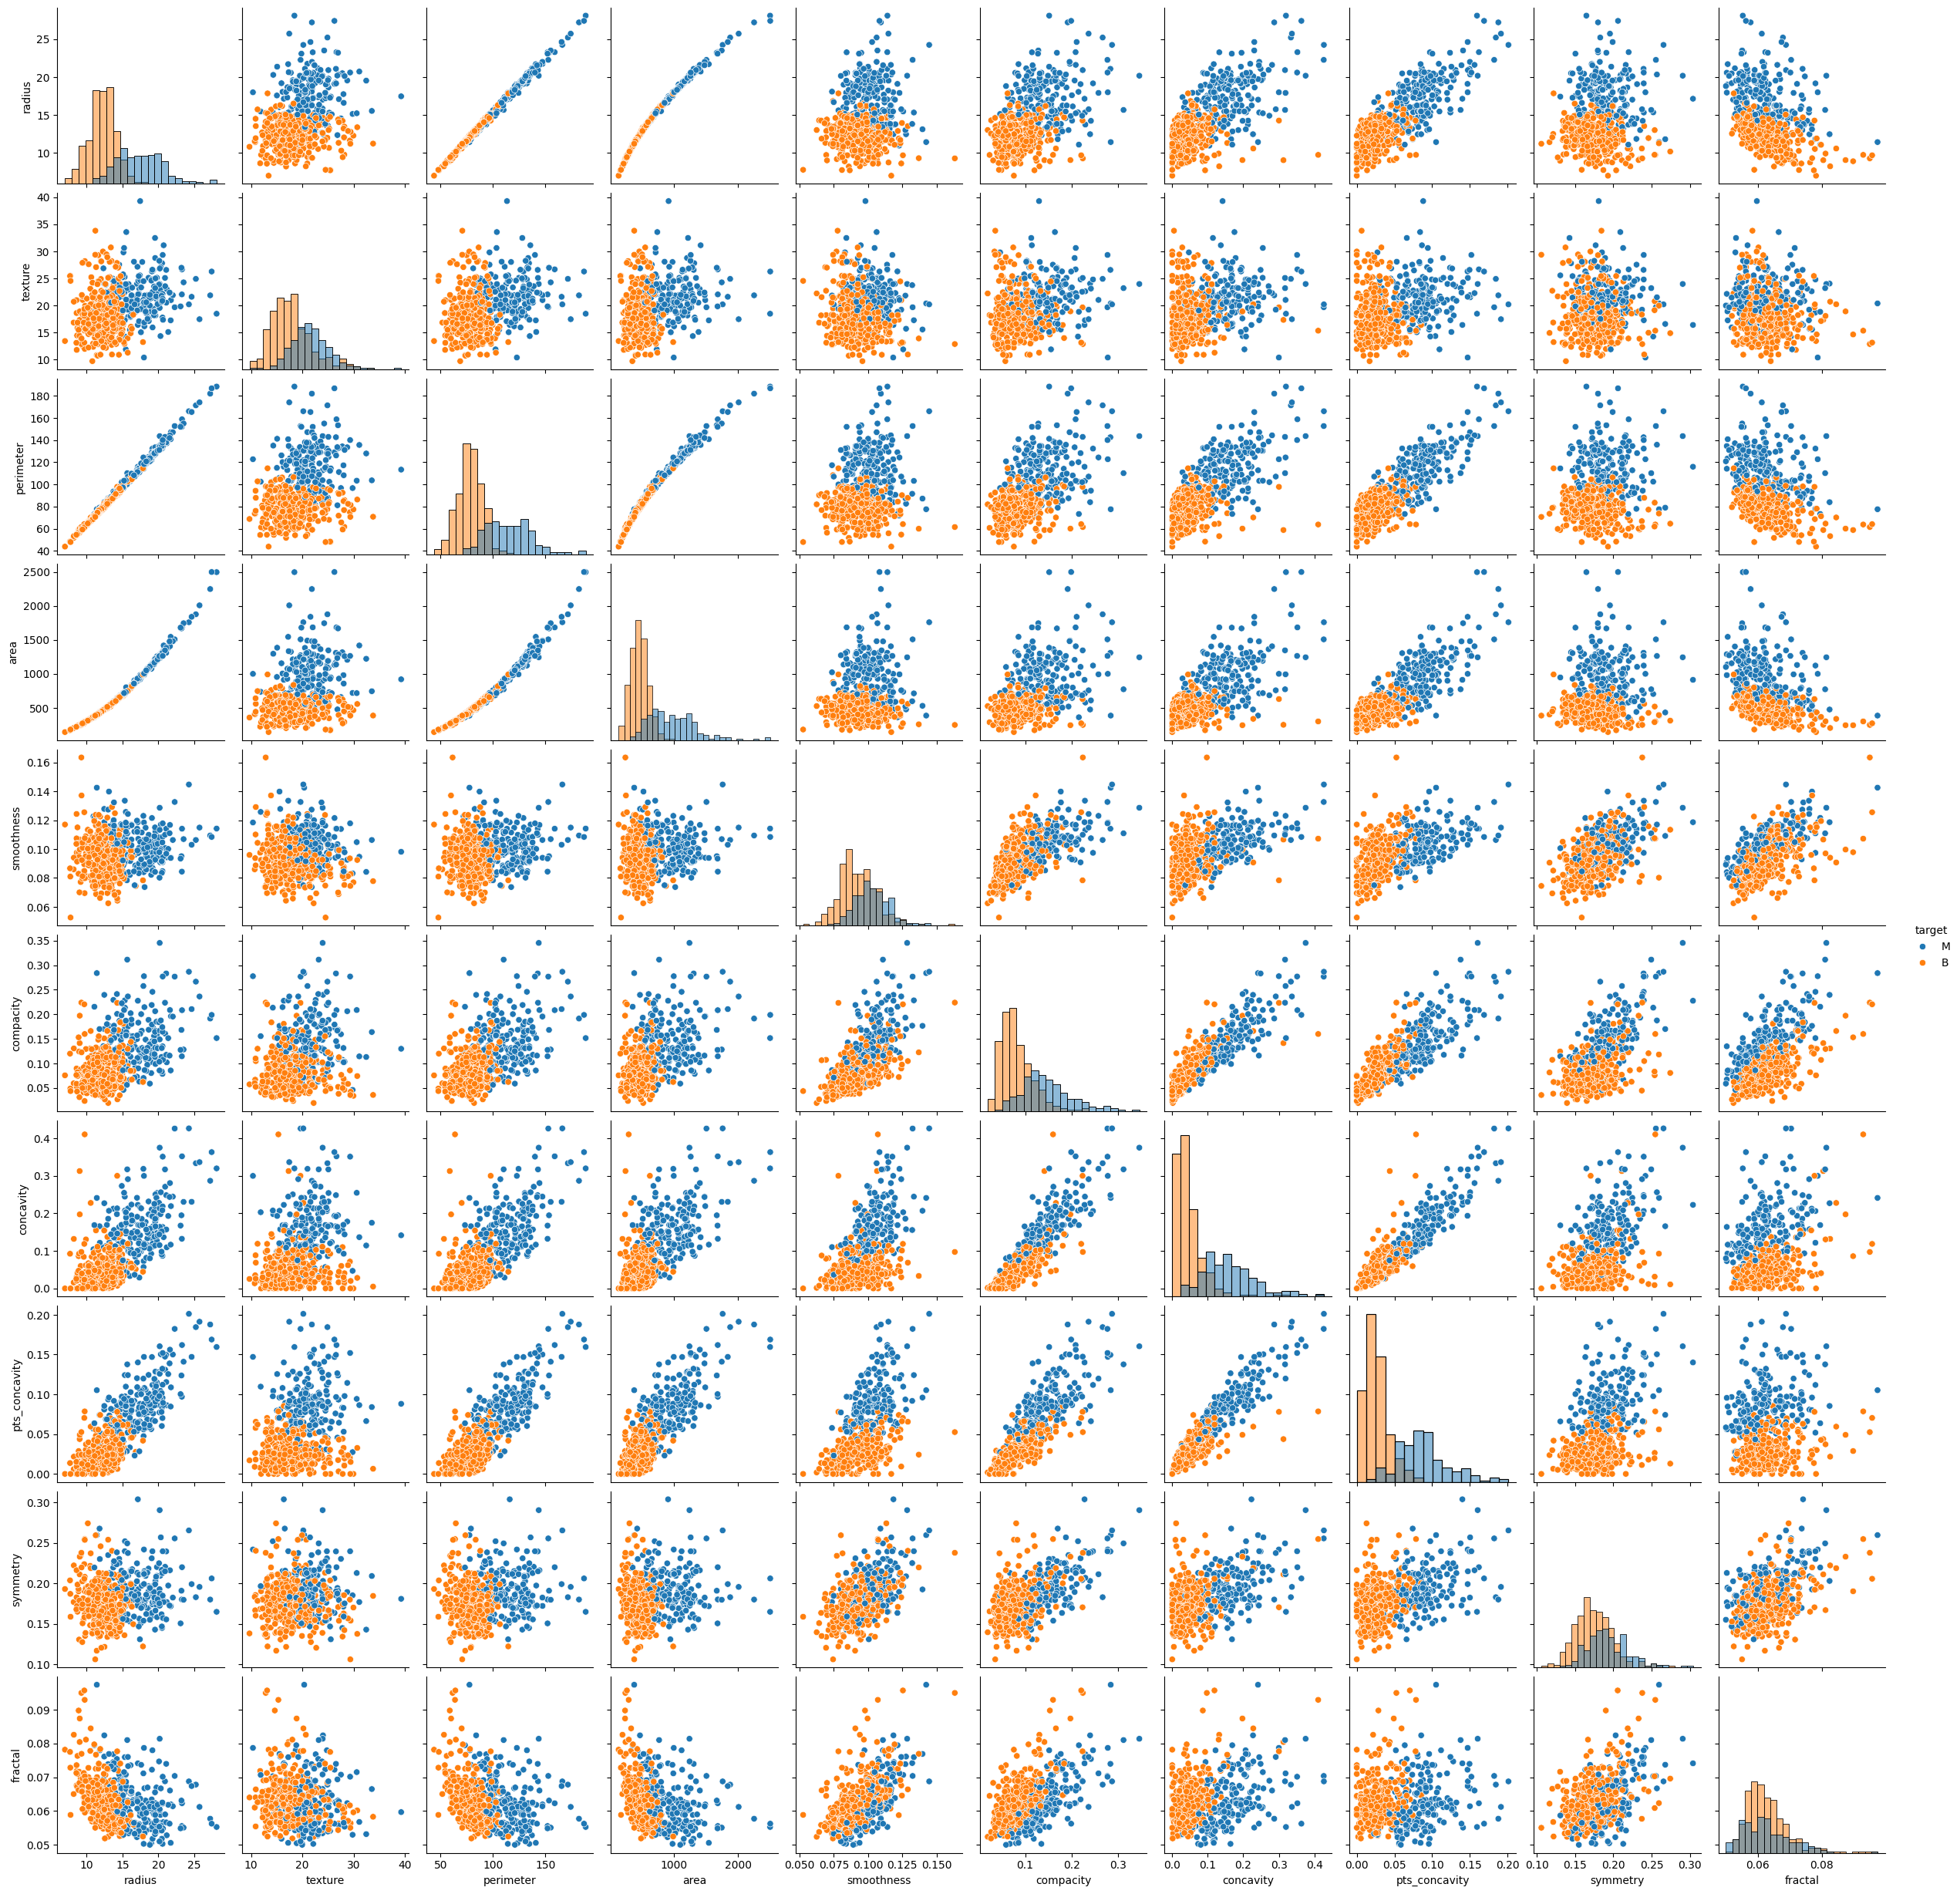

In [51]:
# desired_columns = ['radius', 'texture', 'concavity', 'smoothness', 'compacity', 'symmetry', 'fractal', 'target']
desired_columns = ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compacity', 'concavity', 'pts_concavity', 'symmetry', 'fractal', 'target']
sns.pairplot(dataset[desired_columns], hue='target', diag_kind='hist')

In [52]:
print(dataset[desired_columns].columns)
dataset2 = dataset[desired_columns].drop(columns=['target'], inplace=False)
corr = dataset2.corr().round(2)
print(corr)

Index(['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compacity',
       'concavity', 'pts_concavity', 'symmetry', 'fractal', 'target'],
      dtype='object')
               radius  texture  perimeter  area  smoothness  compacity  \
radius           1.00     0.32       1.00  0.99        0.17       0.51   
texture          0.32     1.00       0.33  0.32       -0.02       0.24   
perimeter        1.00     0.33       1.00  0.99        0.21       0.56   
area             0.99     0.32       0.99  1.00        0.18       0.50   
smoothness       0.17    -0.02       0.21  0.18        1.00       0.66   
compacity        0.51     0.24       0.56  0.50        0.66       1.00   
concavity        0.68     0.30       0.72  0.69        0.52       0.88   
pts_concavity    0.82     0.29       0.85  0.82        0.55       0.83   
symmetry         0.15     0.07       0.18  0.15        0.56       0.60   
fractal         -0.31    -0.08      -0.26 -0.28        0.58       0.57   

               c

In [54]:
# Feature importance
# Prepare dataset
X = dataset.drop(columns=["ID", "target"])
y = LabelEncoder().fit_transform(dataset["target"])  # 1 = Malignant, 0 = Benign

rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

In [55]:
print(importances)

minor_perimeter        0.136217
minor_area             0.127233
minor_pts_concavity    0.125511
pts_concavity          0.098487
minor_radius           0.087023
concavity              0.051233
area                   0.047854
perimeter              0.047454
radius                 0.044267
std_area               0.035118
minor_concavity        0.035044
std_radius             0.017245
minor_texture          0.016579
minor_compacity        0.015898
texture                0.015113
minor_smoothness       0.012612
compacity              0.012575
std_perimeter          0.010365
minor_symmetry         0.009610
std_pts_concavity      0.006858
smoothness             0.006451
minor_fractal          0.006416
std_concavity          0.005810
std_smoothness         0.004866
std_fractal            0.004760
std_compacity          0.004551
std_symmetry           0.003877
std_texture            0.003791
symmetry               0.003742
fractal                0.003438
dtype: float64


In [57]:
X = dataset.drop(columns=["ID", "target"])
y = dataset["target"].map({"B":0, "M":1})  # binário

pipeline = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=42))
pipeline.fit(X, y)

coef = pipeline.named_steps['lassocv'].coef_
selected = pd.Series(coef, index=X.columns)[coef != 0]
print("Variáveis selecionadas pelo Lasso:")
print(selected.sort_values(ascending=False))

/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.020023834780396044, tolerance: 0.00984263736263736
  model = cd_fast.enet_coordinate_descent_gram(
/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.023529341299685314, tolerance: 0.00984263736263736
  model = cd_fast.enet_coordinate_descent_gram(
/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.011313444420906649, tolerance: 0.00984263736263736
  model = cd_fast.enet_coordinate_descent_gram(


Variáveis selecionadas pelo Lasso:
minor_radius           0.550721
std_radius             0.127108
concavity              0.102760
pts_concavity          0.081244
minor_concavity        0.077610
minor_fractal          0.074736
minor_pts_concavity    0.050464
minor_texture          0.046773
std_smoothness         0.045661
std_pts_concavity      0.044152
minor_symmetry         0.042422
texture                0.019101
minor_smoothness       0.018344
std_symmetry           0.007548
std_compacity         -0.002907
std_perimeter         -0.003768
std_texture           -0.004306
fractal               -0.009057
std_fractal           -0.011115
area                  -0.025588
std_area              -0.078541
std_concavity         -0.096273
compacity             -0.170202
minor_area            -0.350787
dtype: float64


In [58]:
zero_selected = pd.Series(coef, index=X.columns)[coef == 0]
print(zero_selected)

radius            -0.0
perimeter         -0.0
smoothness        -0.0
symmetry          -0.0
minor_perimeter   -0.0
minor_compacity   -0.0
dtype: float64


#### Resposta

Visualizando os plots pareados podemos ver que as variáveis perímetro e área podem ser excluidas pois possuem uma alta correlação linear com o raio, 1.0 e 0.99 respectivamente, visto que ele é utilizado no cálculo do perímetro e área, perímetro=2*pi*r e área=pi*r^2.

Além disso, olhando novamente os plots pareados vemos que as variáveis 'pts_concavity' x 'concavity' possuem uma alta correlação. Especificamente, possuem uma coorelação linear de 0.92, mostrando que quanto maior a concavidade maior o número de pontos. 

Outra variável com alta correlação com 'concavity' seria a 'compacity'. Ela mede a compacidade, a qual mede uma relação entre perímetro e área. É uma forma de detectar se a célula é espiculada ou não, padrão conhecido em tumores mamários. Núcleos mais irregulares tendem a ter perímetros maiores em relação à sua área, resultando em valores de compacidade mais altos. Ambas possuem uma forte correlação linear de 0.88.

Entretanto, analisando a importância de cada feature e o resultado da seleção feita pelo Lasso, posso ver que as 3 váriaveis correlacionadas são importantes para o problema. 'pts_concavity' e 'compacity' mostrarem ser uma das variáveis mais importantes para classificar a classe maligna e benigna respectivamente. Caso contrário o lasso teria zerado elas.

Outro insight interessante é que o Lasso zerou a variável 'radius' e 'perimeter' mantendo apenas a variável 'Área'. Isso faz sentido, já que possuem uma relação linear muito forte como vimos antes. Contudo, no caso anterior uma relação linear um pouco mais fraca, já foi o suficiente para não zerar as variáveis.

Outra análise interessante é a variável 'minor_perimeter', a qual foi a mais importante no Random Forest e foi zerada no Lasso. Isso mostra que talvez, essa variável só seja útil em modelos não lineares, como no caso das Redes Neurais.

## Parte II. Treinamento do modelo de Rede Neural - Baseline 

Total: 1,0 pts.

### 1)	Com as configurações do modelo MLP previamente definidas no script, faça o treinamento da Rede Neural sem normalizar os atributos numéricos. Comente o resultado obtido, baseado nas métricas de avaliação disponíveis (acurácia, precision, recall, F1-Score, Matriz de confusão, etc.)

In [71]:
print(dataset.describe())

           radius     texture   perimeter         area  smoothness  \
count  569.000000  569.000000  569.000000   569.000000  569.000000   
mean    14.127292   19.289649   91.969033   654.889104    0.096360   
std      3.524049    4.301036   24.298981   351.914129    0.014064   
min      6.981000    9.710000   43.790000   143.500000    0.052630   
25%     11.700000   16.170000   75.170000   420.300000    0.086370   
50%     13.370000   18.840000   86.240000   551.100000    0.095870   
75%     15.780000   21.800000  104.100000   782.700000    0.105300   
max     28.110000   39.280000  188.500000  2501.000000    0.163400   

        compacity   concavity  pts_concavity    symmetry     fractal  ...  \
count  569.000000  569.000000     569.000000  569.000000  569.000000  ...   
mean     0.104341    0.088799       0.048919    0.181162    0.062798  ...   
std      0.052813    0.079720       0.038803    0.027414    0.007060  ...   
min      0.019380    0.000000       0.000000    0.106000    0

#### Rascunho

In [9]:
new_df = transform_data(dataset.drop(columns=['ID']), normalize=False)
print(dataset.columns)
#new_df.head()

Index(['ID', 'radius', 'texture', 'perimeter', 'area', 'smoothness',
       'compacity', 'concavity', 'pts_concavity', 'symmetry', 'fractal',
       'std_radius', 'std_texture', 'std_perimeter', 'std_area',
       'std_smoothness', 'std_compacity', 'std_concavity', 'std_pts_concavity',
       'std_symmetry', 'std_fractal', 'minor_radius', 'minor_texture',
       'minor_perimeter', 'minor_area', 'minor_smoothness', 'minor_compacity',
       'minor_concavity', 'minor_pts_concavity', 'minor_symmetry',
       'minor_fractal', 'target'],
      dtype='object')


In [10]:
new_df.head()

,radius,texture,perimeter,area,smoothness,compacity,concavity,pts_concavity,symmetry,fractal,...,minor_texture,minor_perimeter,minor_area,minor_smoothness,minor_compacity,minor_concavity,minor_pts_concavity,minor_symmetry,minor_fractal,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [11]:
X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1
  binary = True
else:
  print('Multiclass classification')
  n_output = len(encoder.classes_)
  binary = False
  #y = np.eye(n_output)[y]

Binary classification


In [12]:
batch_size = 32 

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [14]:

#Para o caso de múltiplas classes
#train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
#val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
#test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

In [15]:
#Para o caso binário
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [16]:
train_dataset.X_data

tensor([[1.4640e+01, 1.5240e+01, 9.5770e+01,  ..., 1.3970e-01, 3.1510e-01,
         8.4730e-02],
        [1.5220e+01, 3.0620e+01, 1.0340e+02,  ..., 2.3560e-01, 4.0890e-01,
         1.4090e-01],
        [1.3710e+01, 1.8680e+01, 8.8730e+01,  ..., 1.2840e-01, 2.8490e-01,
         9.0310e-02],
        ...,
        [1.2700e+01, 1.2170e+01, 8.0880e+01,  ..., 8.2240e-02, 2.7750e-01,
         9.4640e-02],
        [1.4600e+01, 2.3290e+01, 9.3970e+01,  ..., 1.3590e-01, 2.4770e-01,
         6.8360e-02],
        [1.2670e+01, 1.7300e+01, 8.1250e+01,  ..., 5.6020e-02, 2.6880e-01,
         6.8880e-02]])

In [17]:
model = NeuralNetwork(n_input = n_input, n_output=n_output,output_activation='sigmoid')

In [18]:
lr = 0.01
epochs = 250

history, y_hat = train(model, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 205.001 | Val Loss: 0.6715 | Train Acc: 59.7500| Val Acc: 60.0000
Epoch 002: | Train Loss: 0.661 | Val Loss: 0.6715 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 003: | Train Loss: 0.661 | Val Loss: 0.6714 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 004: | Train Loss: 0.661 | Val Loss: 0.6714 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 005: | Train Loss: 0.661 | Val Loss: 0.6713 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 006: | Train Loss: 0.661 | Val Loss: 0.6713 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 007: | Train Loss: 0.660 | Val Loss: 0.6713 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 008: | Train Loss: 0.660 | Val Loss: 0.6712 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 009: | Train Loss: 0.660 | Val Loss: 0.6712 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 010: | Train Loss: 0.660 | Val Loss: 0.6712 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 011: | Train Loss: 0.660 | Val Loss: 0.6712 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 012: | Train 

In [19]:
y_pred = model.predict(test_dataset.X_data, binary=binary)

/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.62      1.00      0.77        71
           1       0.00      0.00      0.00        43

    accuracy                           0.62       114
   macro avg       0.31      0.50      0.38       114
weighted avg       0.39      0.62      0.48       114



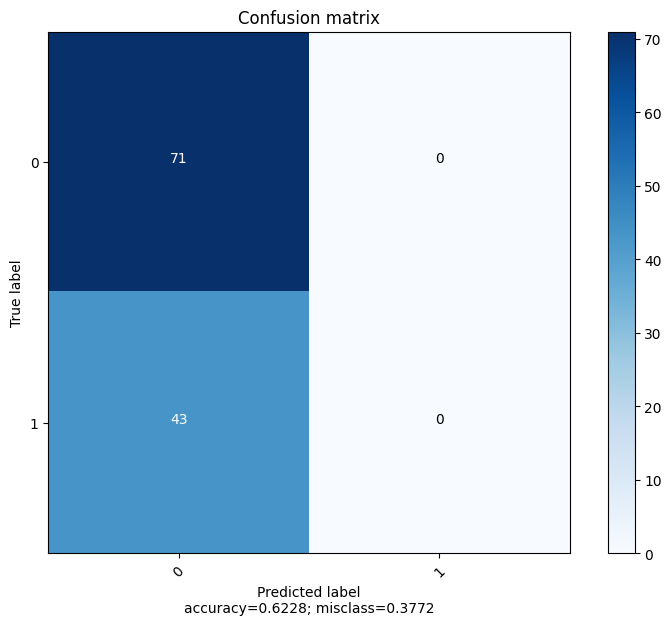

In [20]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

In [21]:
# ...existing code...

# Supondo que você já treinou o modelo e tem a lista de nomes das variáveis de entrada
input_features = new_df.columns[:-1]  # Exclui a coluna target

# Extrai os pesos da primeira camada (fc1)
first_layer_weights = model.fc1.weight.detach().cpu().numpy()

# Cria um DataFrame para facilitar a visualização
weights_df = pd.DataFrame(first_layer_weights, columns=input_features)

print(weights_df.shape)
# Soma dos valores absolutos dos pesos para cada variável (importância agregada)
importance = weights_df.abs().sum(axis=0).sort_values(ascending=False)
print("Importância das variáveis na primeira camada (soma dos pesos absolutos):")
print(importance.head(10))
print(importance.tail(10))
print(importance.std())

# Se quiser visualizar todos os pesos (cada neurônio da camada oculta)
# print("\nPesos da primeira camada (cada linha = neurônio oculto):")
# print(weights_df)

(4, 30)
Importância das variáveis na primeira camada (soma dos pesos absolutos):
minor_area         23.285978
area               19.131611
minor_perimeter     3.887874
perimeter           3.343806
std_area            1.404661
minor_texture       1.071710
texture             0.997804
minor_radius        0.781867
radius              0.712402
std_texture         0.632373
dtype: float32
std_perimeter          0.384012
minor_pts_concavity    0.369183
std_fractal            0.360383
pts_concavity          0.342525
minor_smoothness       0.335549
compacity              0.335422
std_pts_concavity      0.313875
fractal                0.312880
std_smoothness         0.247815
minor_compacity        0.218021
dtype: float32
5.2861357


In [22]:
print(dataset.describe())

           radius     texture   perimeter         area  smoothness  \
count  569.000000  569.000000  569.000000   569.000000  569.000000   
mean    14.127292   19.289649   91.969033   654.889104    0.096360   
std      3.524049    4.301036   24.298981   351.914129    0.014064   
min      6.981000    9.710000   43.790000   143.500000    0.052630   
25%     11.700000   16.170000   75.170000   420.300000    0.086370   
50%     13.370000   18.840000   86.240000   551.100000    0.095870   
75%     15.780000   21.800000  104.100000   782.700000    0.105300   
max     28.110000   39.280000  188.500000  2501.000000    0.163400   

        compacity   concavity  pts_concavity    symmetry     fractal  ...  \
count  569.000000  569.000000     569.000000  569.000000  569.000000  ...   
mean     0.104341    0.088799       0.048919    0.181162    0.062798  ...   
std      0.052813    0.079720       0.038803    0.027414    0.007060  ...   
min      0.019380    0.000000       0.000000    0.106000    0

#### Resposta

Por causa da não normalização dos dados, o modelo acaba atribuindo pesos maiores à variáveis com escala maior, como por exemplo variáveis associadas a área e perímetro. Isso fica evidente quando analisamos a soma dos pesos dos neurônios referentes a variável em questão na primeira camada. Botando em ordem decrescente, vemos que as menores somas são referentes a variáveis com escala muito pequena, média entre 0 e 1, enquanto a média da variável área, e oriundas dela, fica em torno de 600. Sendo assim, a consequência disso no aprendizado é a não descriminação dos dados em maligno e, portanto, o modelo acabou aprendendo apenas a classe benigna pois é a mais fácil.

## Parte III - Mudança de configurações do modelo

Total: 5,0 pts.

### 1)	Agora normalize os dados de entrada e treine novamente o modelo MLP. Avalie os resultados obtidos e comente o efeito da normalização no treinamento da Rede Neural.

#### Rascunho

In [41]:
new_df = transform_data(dataset, normalize=True)
new_df.head()

/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

,ID_8670,ID_8913,ID_8915,ID_9047,ID_85715,ID_86208,ID_86211,ID_86355,ID_86408,ID_86409,...,minor_texture,minor_perimeter,minor_area,minor_smoothness,minor_compacity,minor_concavity,minor_pts_concavity,minor_symmetry,minor_fractal,target
0,0,0,0,0,0,0,0,0,0,0,...,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864,M
1,0,0,0,0,0,0,0,0,0,0,...,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878,M
2,0,0,0,0,0,0,0,0,0,0,...,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433,M
3,0,0,0,0,0,0,0,0,0,0,...,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711,M
4,0,0,0,0,0,0,0,0,0,0,...,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595,M


In [42]:
X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1

else:
  print('Multiclass classification')
  #y = to_categorical(y)
  n_output = encoder.classes_.shape[0]


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

Binary classification


In [43]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [44]:
epochs = 250
model = NeuralNetwork(n_input = n_input, n_output=n_output,output_activation='sigmoid')
history, y_hat = train(model, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 0.674 | Val Loss: 0.6765 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 002: | Train Loss: 0.673 | Val Loss: 0.6751 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 003: | Train Loss: 0.671 | Val Loss: 0.6738 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 004: | Train Loss: 0.670 | Val Loss: 0.6725 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 005: | Train Loss: 0.668 | Val Loss: 0.6712 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 006: | Train Loss: 0.667 | Val Loss: 0.6699 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 007: | Train Loss: 0.665 | Val Loss: 0.6686 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 008: | Train Loss: 0.664 | Val Loss: 0.6674 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 009: | Train Loss: 0.662 | Val Loss: 0.6662 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 010: | Train Loss: 0.661 | Val Loss: 0.6649 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 011: | Train Loss: 0.659 | Val Loss: 0.6637 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 012: | Train Lo

#### Resposta

In [45]:
y_pred = model.predict(test_dataset.X_data,binary=binary)


              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



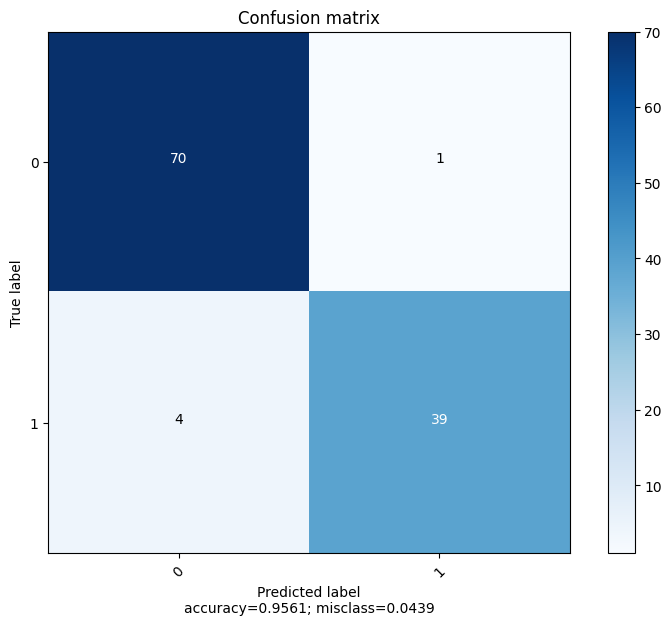

In [46]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

In [102]:
# ...existing code...

# Supondo que você já treinou o modelo e tem a lista de nomes das variáveis de entrada
input_features = new_df.columns[:-1]  # Exclui a coluna target

# Extrai os pesos da primeira camada (fc1)
first_layer_weights = model.fc1.weight.detach().cpu().numpy()

# Cria um DataFrame para facilitar a visualização
weights_df = pd.DataFrame(first_layer_weights, columns=input_features)

print(weights_df.shape)
# Soma dos valores absolutos dos pesos para cada variável (importância agregada)
importance = weights_df.abs().sum(axis=0).sort_values(ascending=False)
print("Importância das variáveis na primeira camada (soma dos pesos absolutos):")
print(importance.head(10))
print(importance.tail(10))
print(importance.std())

# Se quiser visualizar todos os pesos (cada neurônio da camada oculta)
# print("\nPesos da primeira camada (cada linha = neurônio oculto):")
# print(weights_df)

(4, 599)
Importância das variáveis na primeira camada (soma dos pesos absolutos):
minor_pts_concavity    1.325992
pts_concavity          1.249212
concavity              1.085662
minor_radius           0.906982
minor_perimeter        0.892547
minor_concavity        0.861110
minor_area             0.775904
area                   0.704017
perimeter              0.697085
minor_compacity        0.645837
dtype: float32
ID_859471       0.033619
ID_911320502    0.032000
ID_904357       0.029588
ID_91858        0.028765
ID_907915       0.028671
ID_91805        0.028366
ID_861853       0.025306
ID_8712291      0.023298
ID_8811842      0.021415
ID_868999       0.017701
dtype: float32
0.12407589


Com a normalização as contribuições de cada variável ficam equidistribuídas possibilitando a discriminação das variáveis pela rede neural. Isso fica evidente olhando a matriz de confusão que agora apresenta valores positivos na diagonal principal e 0 na diagonal secundária. Além disso, é possível observar o desvio padrão da soma dos pesos de cada variável na primeira camada, assim como foi feito na questão anterior: 5.2 e 0.12 para o primeiro e segundo experimentos respectivamente Fica evidente que no primeiro experimento os pesos estão mais dispersos, devido às variáveis com escala maior.

### 2)	Modifique o tempo de treinamento (épocas) da Rede Neural. Escolha valores distintos (e.g. 1 e 1000 épocas) e avalie os resultados.

#### Rascunho

In [23]:
new_df = transform_data(dataset, normalize=True)
new_df.head()

X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1

else:
  print('Multiclass classification')
  #y = to_categorical(y)
  n_output = encoder.classes_.shape[0]


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)


/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

Binary classification


/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

In [24]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)

In [30]:
epochs = 1
model_1 = NeuralNetwork(n_input = n_input, n_output=n_output,output_activation='sigmoid')
history, y_hat = train(model_1, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 0.693 | Val Loss: 0.6922 | Train Acc: 56.4167| Val Acc: 60.0000


In [31]:
epochs = 1000
model_1000 = NeuralNetwork(n_input = n_input, n_output=n_output,output_activation='sigmoid')
history, y_hat = train(model_1000, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 0.672 | Val Loss: 0.6769 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 002: | Train Loss: 0.671 | Val Loss: 0.6764 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 003: | Train Loss: 0.670 | Val Loss: 0.6759 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 004: | Train Loss: 0.669 | Val Loss: 0.6755 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 005: | Train Loss: 0.669 | Val Loss: 0.6751 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 006: | Train Loss: 0.668 | Val Loss: 0.6747 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 007: | Train Loss: 0.667 | Val Loss: 0.6744 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 008: | Train Loss: 0.667 | Val Loss: 0.6741 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 009: | Train Loss: 0.666 | Val Loss: 0.6738 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 010: | Train Loss: 0.666 | Val Loss: 0.6735 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 011: | Train Loss: 0.665 | Val Loss: 0.6733 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 012: | Train Lo

#### Resposta

In [33]:
y_pred_1 = model_1.predict(test_dataset.X_data,binary=binary)

              precision    recall  f1-score   support

           0       0.62      0.99      0.76        71
           1       0.00      0.00      0.00        43

    accuracy                           0.61       114
   macro avg       0.31      0.49      0.38       114
weighted avg       0.39      0.61      0.47       114



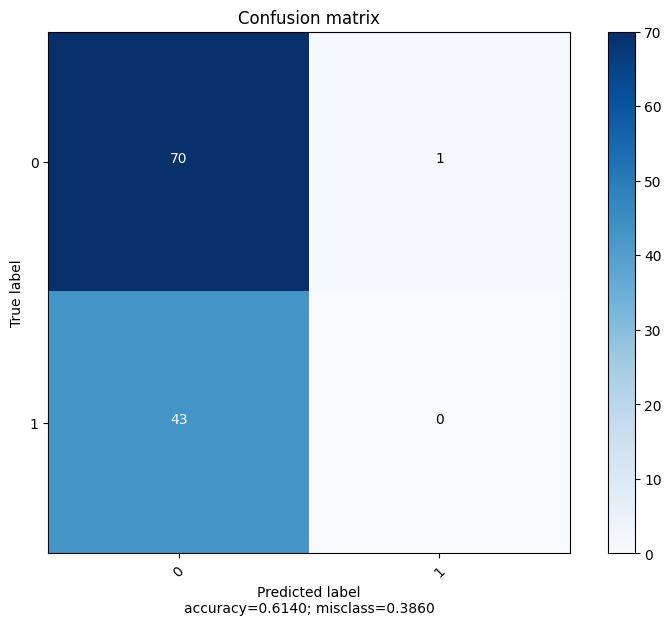

In [34]:
print(classification_report(y_test, y_pred_1))

cm = confusion_matrix(y_test, y_pred_1)

plot_confusion_matrix(cm)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



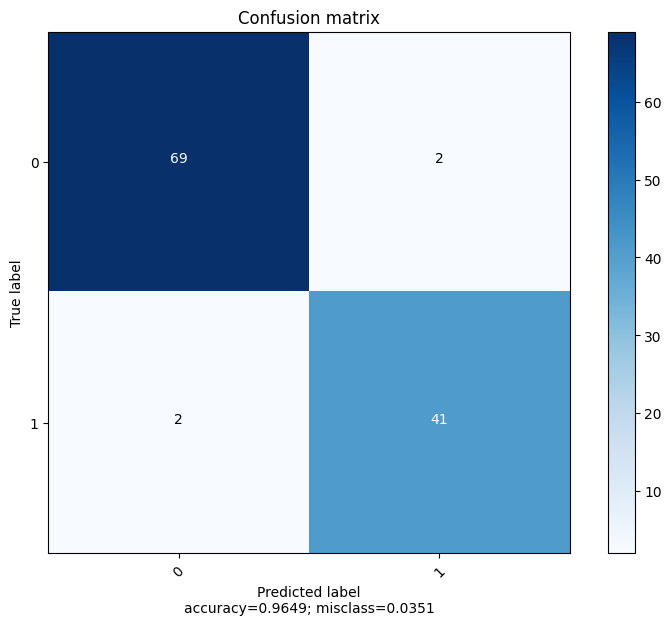

In [36]:
y_pred_1000 = model_1000.predict(test_dataset.X_data,binary=binary)
print(classification_report(y_test, y_pred_1000))

cm = confusion_matrix(y_test, y_pred_1000)

plot_confusion_matrix(cm)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



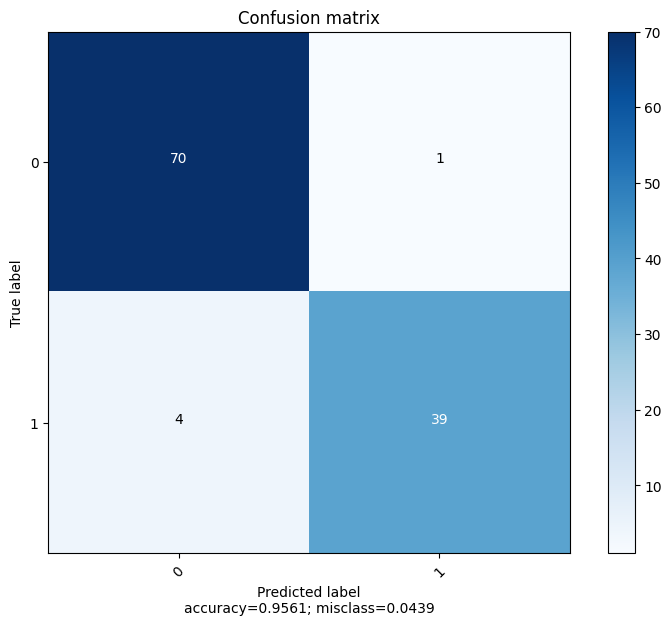

In [47]:
y_pred = model.predict(test_dataset.X_data,binary=binary)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

Podemos observar que com apenas 1 época o modelo não consegue aprender a classe positiva. Quando aumentamos para 1000 épocas o modelo apresenta bom resultado e consegue discriminar as duas classes. Além disso, o modelo apresenmta uma ligeira melhora comparado ao baseline de 250 épocas. É importante frisar que, 1000 épocas pode ser um número demasiadamente alto e pode levar ao overfitting, fazendo com que o modelo não generalize bem em dados externos. Talvez o conjunto de testes utilizado seja muito próximo do conjunto de treino e por isso não ficou tão evidente o overfitting.

### 3)	 Modifique a taxa de aprendizado da Rede Neural. Escolha valores distintos (e.g. 0,001 e 0,1) e avalie os resultados.

#### Rascunho

In [55]:
new_df = transform_data(dataset, normalize=True)
new_df.head()

X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1

else:
  print('Multiclass classification')
  #y = to_categorical(y)
  n_output = encoder.classes_.shape[0]


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

Binary classification


/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

In [56]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)

In [57]:
epochs = 250
lr = 0.001

In [58]:
model_lr1 = NeuralNetwork(n_input = n_input, n_output=n_output,output_activation='sigmoid')
history_lr1, y_hat = train(model_lr1, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 0.706 | Val Loss: 0.7027 | Train Acc: 36.8333| Val Acc: 40.0000
Epoch 002: | Train Loss: 0.705 | Val Loss: 0.7025 | Train Acc: 36.8333| Val Acc: 40.0000
Epoch 003: | Train Loss: 0.705 | Val Loss: 0.7022 | Train Acc: 36.8333| Val Acc: 40.0000
Epoch 004: | Train Loss: 0.705 | Val Loss: 0.7020 | Train Acc: 36.8333| Val Acc: 40.0000
Epoch 005: | Train Loss: 0.704 | Val Loss: 0.7018 | Train Acc: 36.8333| Val Acc: 40.0000
Epoch 006: | Train Loss: 0.704 | Val Loss: 0.7015 | Train Acc: 36.8333| Val Acc: 40.0000
Epoch 007: | Train Loss: 0.704 | Val Loss: 0.7013 | Train Acc: 36.8333| Val Acc: 40.0000
Epoch 008: | Train Loss: 0.704 | Val Loss: 0.7010 | Train Acc: 36.8333| Val Acc: 40.0000
Epoch 009: | Train Loss: 0.703 | Val Loss: 0.7008 | Train Acc: 36.8333| Val Acc: 40.0000
Epoch 010: | Train Loss: 0.703 | Val Loss: 0.7006 | Train Acc: 36.8333| Val Acc: 40.0000
Epoch 011: | Train Loss: 0.703 | Val Loss: 0.7004 | Train Acc: 36.8333| Val Acc: 40.0000
Epoch 012: | Train Lo

In [59]:
lr = 0.1
model_lr2 = NeuralNetwork(n_input = n_input, n_output=n_output,output_activation='sigmoid')
history_lr2, y_hat = train(model_lr2, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 0.669 | Val Loss: 0.6714 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 002: | Train Loss: 0.660 | Val Loss: 0.6654 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 003: | Train Loss: 0.652 | Val Loss: 0.6593 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 004: | Train Loss: 0.644 | Val Loss: 0.6529 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 005: | Train Loss: 0.636 | Val Loss: 0.6463 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 006: | Train Loss: 0.628 | Val Loss: 0.6391 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 007: | Train Loss: 0.619 | Val Loss: 0.6302 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 008: | Train Loss: 0.608 | Val Loss: 0.6201 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 009: | Train Loss: 0.596 | Val Loss: 0.6085 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 010: | Train Loss: 0.582 | Val Loss: 0.5956 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 011: | Train Loss: 0.567 | Val Loss: 0.5759 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 012: | Train Lo

#### Resposta

/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.62      1.00      0.77        71
           1       0.00      0.00      0.00        43

    accuracy                           0.62       114
   macro avg       0.31      0.50      0.38       114
weighted avg       0.39      0.62      0.48       114



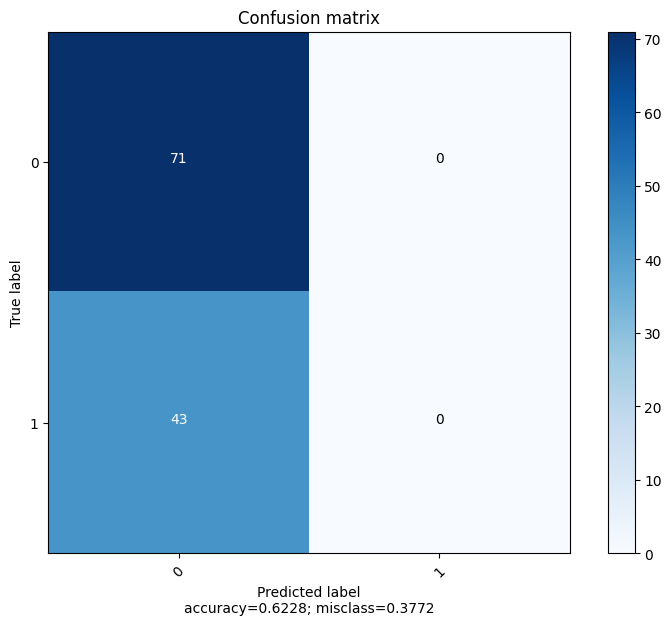

In [60]:
y_pred = model_lr1.predict(test_dataset.X_data,binary=binary)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



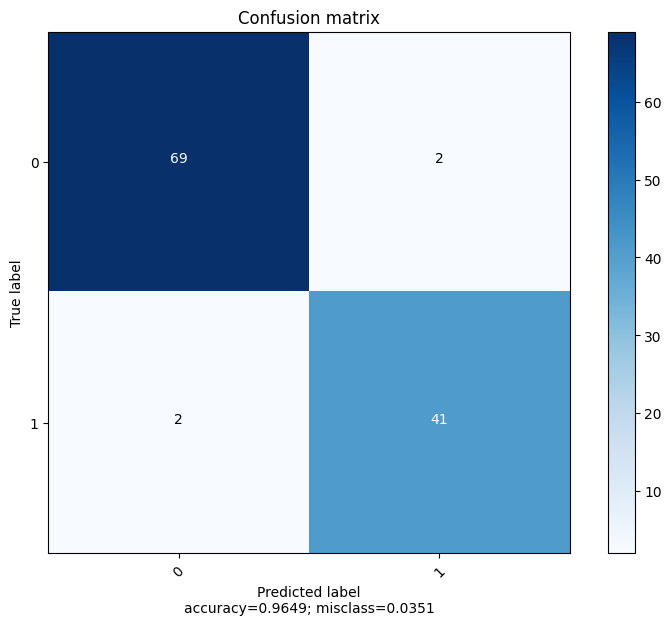

In [61]:
y_pred = model_lr2.predict(test_dataset.X_data,binary=binary)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

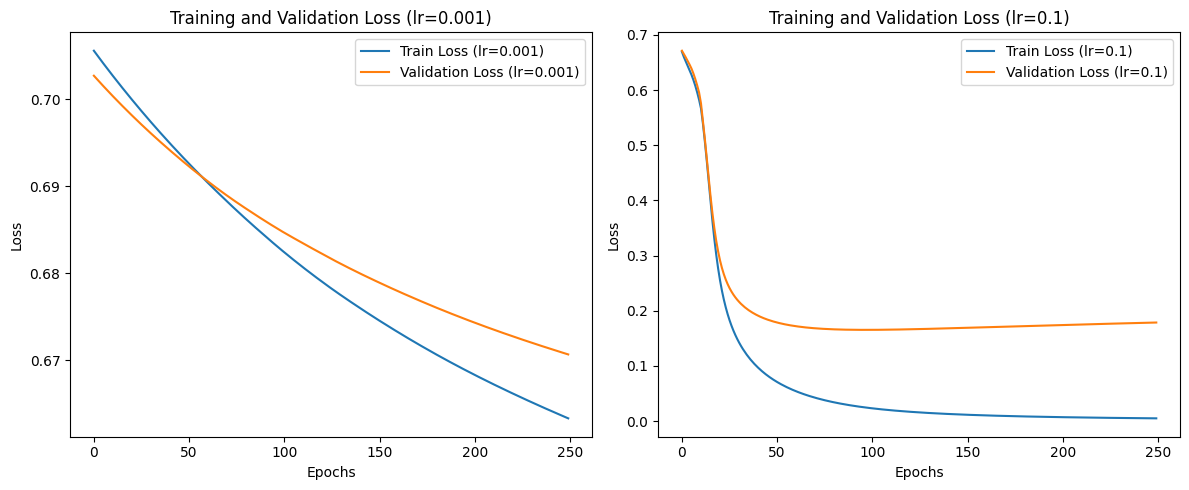

In [63]:
# Plot both histories side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_lr1['loss_train'], label='Train Loss (lr=0.001)')
plt.plot(history_lr1['loss_val'], label='Validation Loss (lr=0.001)')
plt.title('Training and Validation Loss (lr=0.001)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_lr2['loss_train'], label='Train Loss (lr=0.1)')
plt.plot(history_lr2['loss_val'], label='Validation Loss (lr=0.1)')
plt.title('Training and Validation Loss (lr=0.1)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Com a learning rate mais alta o modelo tem a possibilidade de aprender mais rápido, ou seja, os passos são mais largos no nosso processo de otimização em busca dos pesos ideias da nossa rede neural. No nosso caso, parece que o problema possui poucos mínimos locais, possibilitando uma convergência rápida com taxa de aprendizado alta. Isso fica evidente olhando o histórico da função de custo para treino e validação ao longo do treinamento. Podemos ver que para a taxa de aprendizagem alta o custo chegou próximo de zero e teve uma acurácia próxima de 0.96 no dataset de test. Já o experimento com taxa de aprendizagem mais baixa, para o mesmo número de épocas não decaiu tanto o valor do custo, pois os passos do otimizador são mais curtos acarretando em mudanças menores nos pesos e necessitando de um número maior de épocas para convergir ao mínimo esperado. Além disso, vemos que no dataset de teste este modelo aprendeu apenas a primeira classe, confirmando a necessidade de mais épocas para uma melhor generalização.

### 4)	Modifique a quantidade de neurônios na camada escondida da Rede Neural. Escolha valores distintos (e.g. 2 e 70 neurônios) e avalie os resultados.

#### Rascunho

In [64]:
new_df = transform_data(dataset, normalize=True)
new_df.head()

X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1

else:
  print('Multiclass classification')
  #y = to_categorical(y)
  n_output = encoder.classes_.shape[0]


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

Binary classification


/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[f'{name}_{k}'] = dummy_y[:,j].astype('int')
/home/thiago/Redes_Neurais/PUC_Redes_Neurais/pos_grad/lista 1/utils.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

In [65]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)

In [66]:
epochs = 250
lr = 0.01

In [67]:
model_exp1 = NeuralNetwork(n_input=n_input, hidden_neurons=2, n_output=n_output, output_activation='sigmoid')
history_exp1, y_hat = train(model_exp1, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 0.661 | Val Loss: 0.6797 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 002: | Train Loss: 0.661 | Val Loss: 0.6794 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 003: | Train Loss: 0.660 | Val Loss: 0.6792 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 004: | Train Loss: 0.660 | Val Loss: 0.6789 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 005: | Train Loss: 0.660 | Val Loss: 0.6786 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 006: | Train Loss: 0.660 | Val Loss: 0.6784 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 007: | Train Loss: 0.660 | Val Loss: 0.6781 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 008: | Train Loss: 0.660 | Val Loss: 0.6779 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 009: | Train Loss: 0.660 | Val Loss: 0.6777 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 010: | Train Loss: 0.659 | Val Loss: 0.6775 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 011: | Train Loss: 0.659 | Val Loss: 0.6773 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 012: | Train Lo

In [68]:
model_exp2 = NeuralNetwork(n_input=n_input, hidden_neurons=70, n_output=n_output, output_activation='sigmoid')
history_exp2, y_hat = train(model_exp2, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 0.687 | Val Loss: 0.6880 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 002: | Train Loss: 0.685 | Val Loss: 0.6862 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 003: | Train Loss: 0.683 | Val Loss: 0.6844 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 004: | Train Loss: 0.681 | Val Loss: 0.6827 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 005: | Train Loss: 0.679 | Val Loss: 0.6811 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 006: | Train Loss: 0.677 | Val Loss: 0.6796 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 007: | Train Loss: 0.675 | Val Loss: 0.6781 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 008: | Train Loss: 0.673 | Val Loss: 0.6766 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 009: | Train Loss: 0.671 | Val Loss: 0.6752 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 010: | Train Loss: 0.670 | Val Loss: 0.6739 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 011: | Train Loss: 0.668 | Val Loss: 0.6726 | Train Acc: 63.1667| Val Acc: 60.0000
Epoch 012: | Train Lo

#### Resposta

/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/thiago/python-envs/base/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.62      1.00      0.77        71
           1       0.00      0.00      0.00        43

    accuracy                           0.62       114
   macro avg       0.31      0.50      0.38       114
weighted avg       0.39      0.62      0.48       114



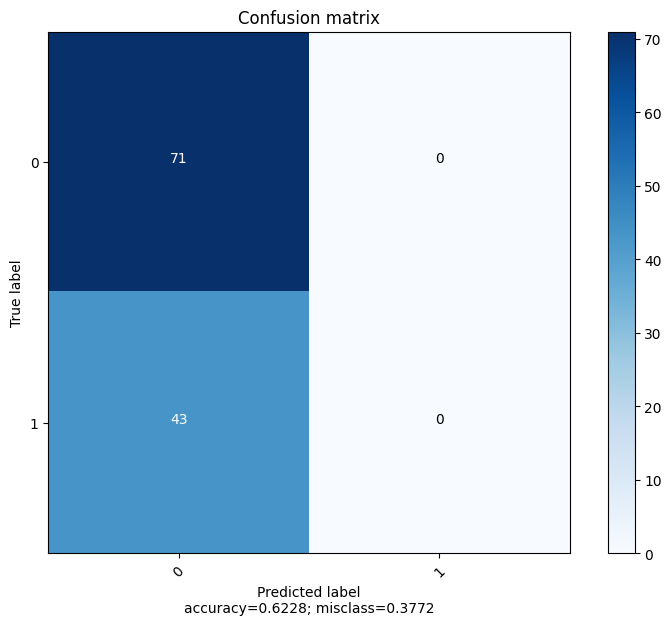

In [69]:
y_pred = model_exp1.predict(test_dataset.X_data,binary=binary)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



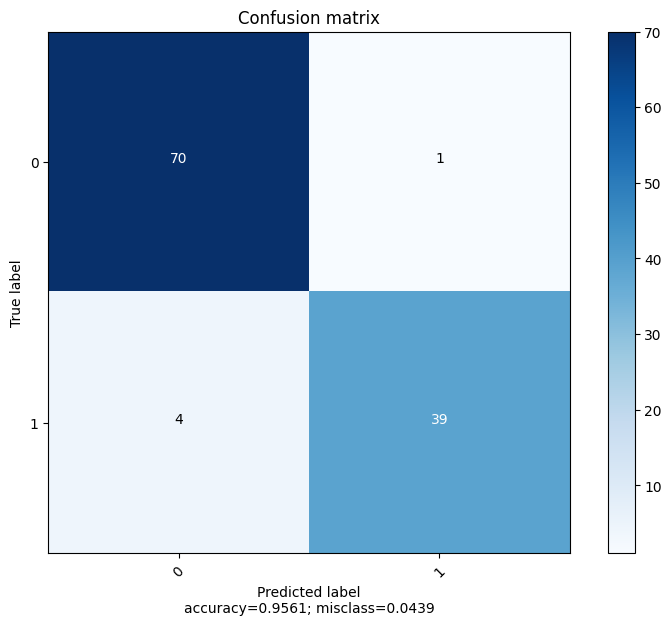

In [70]:
y_pred = model_exp2.predict(test_dataset.X_data,binary=binary)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

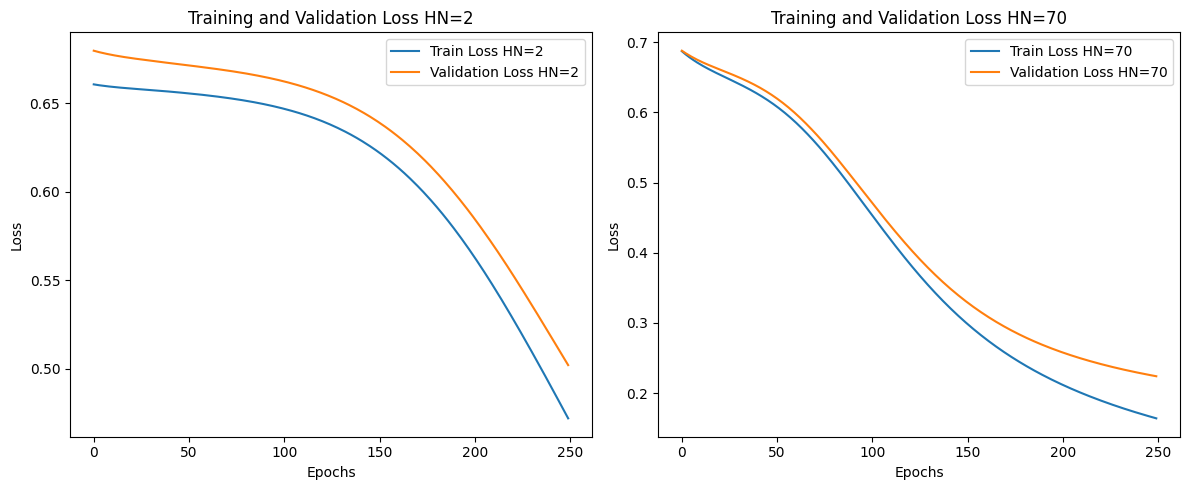

In [72]:
# Plot both histories side by side
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_exp1['loss_train'], label='Train Loss HN=2')
plt.plot(history_exp1['loss_val'], label='Validation Loss HN=2')
plt.title('Training and Validation Loss HN=2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_exp2['loss_train'], label='Train Loss HN=70')
plt.plot(history_exp2['loss_val'], label='Validation Loss HN=70')
plt.title('Training and Validation Loss HN=70')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Podemos ver que o experimento com mais neurônios na camada escondida foi o que melhor performou em termos de acurácia, para um mesmo valor de taxa de aprendizagem e número de épocas. Isso fica evidente olhando para a função de custo, a qual podemos ver que a quantidade de neurônios a mais permitiu reduzir o erro durante o treinamento, ou seja, generalizar melhor. Com uma maior quantidade de parâmetros aumenta-se a quantidade de hiperplanos para conseguir separar melhor as variáveis, o que resulta em uma melhor discriminação delas. 

## Parte IV - Usando outras técnicas para Redes Neurais 
Total: 3,0 pts.

### 1)	Implemente a técnica de parada antecipada (Early Stopping) usando o conjunto de validação. Avalie o resultado obtido.

OBS: para essa questão, copie a função `train` do arquivo `model_utils.py`, copie neste notebook e faça as adaptações necessárias.

#### Rascunho

#### Resposta

### 2)	Faça novos testes para avaliar o desempenho da Rede Neural no problema designado usando a técnica K-Fold (com K = 10). Comente o resultado obtido.

Dica: não é necessário utilizar a ferramenta KFold do scikit-learn para o desenvolvimento deste item. Uma alternativa <b> simples </b> é fazer um *for loop*, selecionando os índices em bloco. 

#### Rascunho

#### Resposta

### 3)	Faça análises e novas implementações que você julgue importante para o seu trabalho. Não esqueça de explicar a motivação da análise realizada. 

#### Rascunho

#### Resposta